# Paladin study — what he sees, and whether it survives contact with data

Source: `studies/material/paladin/analysis/` (UTC pack, 217 positions, 173 backtestable).
OHLCV: Binance USDT-M futures 15m in study-local `paladin_ohlcv.db` (prod untouched), BTC/ETH 1m from prod read-only.

Pipeline: `fetch_ohlcv.py → venue_offset.py → run_h0.py → entry_context.py → resolve_and_exits.py`. This notebook presents their `results/`. Findings prose: `findings.md`.

In [1]:
import os, sys, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../../material/paladin/analysis'))
from paladin_data import load_ohlcv, load_pack
pd.set_option('display.width', 160)

d = load_pack()
pos = d['positions']
bt = pos[pos.is_backtestable]
print(f"positions {len(pos)}, backtestable {len(bt)}, "
      f"window {pos.signal_time_utc.min():%Y-%m-%d} -> {pos.signal_time_utc.max():%Y-%m-%d}")
print(f"symbols with data: ", end='')
con = sqlite3.connect('paladin_ohlcv.db')
have = {r[0] for r in con.execute('SELECT DISTINCT symbol FROM klines_15m')}
con.close()
missing = sorted(set(bt.symbol) - have)
print(f"{len(set(bt.symbol) & have)}/{bt.symbol.nunique()}  (missing: {missing})")


positions 217, backtestable 173, window 2026-05-06 -> 2026-08-21
symbols with data: 53/53  (missing: [])


## 1. Can we trust the price join? (venue offset)
He traded Blofin/MEXC/Bybit/Yubit/Binance; we join 981 prices he actually typed to our bars.

965 of his quoted prices joined to Binance 15m bars
inside-bar share 54.4%   median dist-to-range 0.000%   p90 2.752%


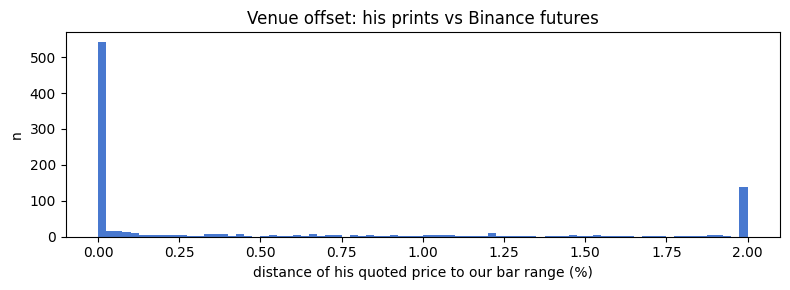

In [2]:
off = pd.read_csv('results/venue_offset.csv')
print(f"{len(off)} of his quoted prices joined to Binance 15m bars")
print(f"inside-bar share {off.inside_bar.mean()*100:.1f}%   "
      f"median dist-to-range {off.dist_to_range_pct.median():.3f}%   "
      f"p90 {off.dist_to_range_pct.quantile(.9):.3f}%")
fig, ax = plt.subplots(figsize=(8,3))
ax.hist(off.dist_to_range_pct.clip(0, 2), bins=80, color='#4878cf')
ax.set_xlabel('distance of his quoted price to our bar range (%)'); ax.set_ylabel('n')
ax.set_title('Venue offset: his prints vs Binance futures'); plt.tight_layout()


## 2. H0 — trade his published plan mechanically
Entry at his ref price on signal, exit at published stop or TP1, conservative ambiguity (stop wins a spanning bar). Variants: time cap 24/72/168/700h × (plain | stop-to-BE at +1R).

,variant,n,expectancy_r,median_r,hit_rate_pct,total_r,his_expectancy_r,his_hit_rate_pct
0,24h,173,0.071,0.104,56.069,12.214,1.637,89.72
1,24h_be1r,173,0.062,0.072,53.757,10.790,1.637,89.72
2,24h_mktfill,173,0.003,0.025,51.445,0.568,1.637,89.72
3,72h,173,0.003,0.056,53.179,0.496,1.637,89.72
4,72h_be1r,173,0.028,0.000,49.133,4.898,1.637,89.72
5,72h_mktfill,173,-0.062,0.010,50.867,-10.783,1.637,89.72
6,168h,173,0.015,-0.322,47.977,2.547,1.637,89.72
7,168h_be1r,173,0.051,0.000,41.618,8.837,1.637,89.72
8,168h_mktfill,173,-0.050,-0.360,47.977,-8.639,1.637,89.72
9,700h,173,0.215,-1.000,43.931,37.253,1.637,89.72


same 107 positions:  mechanical +0.333R/trade  vs his +1.637R/trade


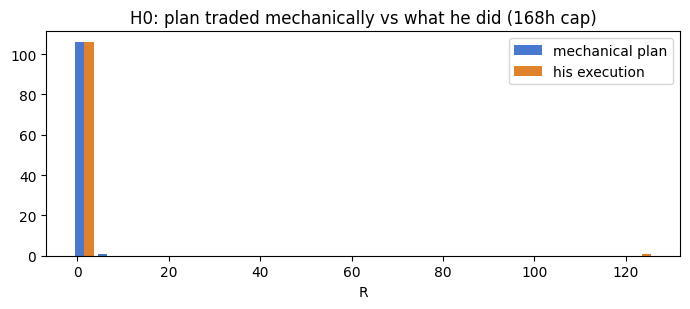

In [3]:
s = pd.read_csv('results/h0_summary.csv')
cols = ['variant','n','expectancy_r','median_r','hit_rate_pct','total_r',
        'his_expectancy_r','his_hit_rate_pct']
display(s[cols].round(3))
rep = pd.read_csv('results/h0_replay_168h.csv').dropna(subset=['r'])
both = rep.dropna(subset=['his_r'])
fig, ax = plt.subplots(figsize=(7,3.2))
ax.hist([both.r, both.his_r], bins=25, label=['mechanical plan','his execution'],
        color=['#4878cf','#e1812c'])
ax.legend(); ax.set_xlabel('R'); ax.set_title('H0: plan traded mechanically vs what he did (168h cap)')
plt.tight_layout()
print(f"same {len(both)} positions:  mechanical {both.r.mean():+.3f}R/trade  "
      f"vs his {both.his_r.mean():+.3f}R/trade")


## 3. What the market looks like when he enters
Each feature vs matched controls (same symbol, same time-of-day, random dates, no lookahead).

,feature,his trades,matched controls
0,long after new 1d low (H2),0.305,0.247
1,short after new 1d high (H2),0.571,0.233
2,long after new 3d low (H2),0.191,0.148
3,short after new 3d high (H2),0.476,0.138
4,long after new 7d low (H2),0.107,0.091
5,short after new 7d high (H2),0.357,0.087
6,"range position, longs (H10, median)",0.405,0.502
7,"entry vs 4h EMA200 in ATRs, longs (H4, median)",-0.620,-1.484
8,signal in first 30min of 4h candle (H3),0.145,0.145


H5 stop%% vs ATR%%: pearson 0.59, spearman 0.75 (n=173)


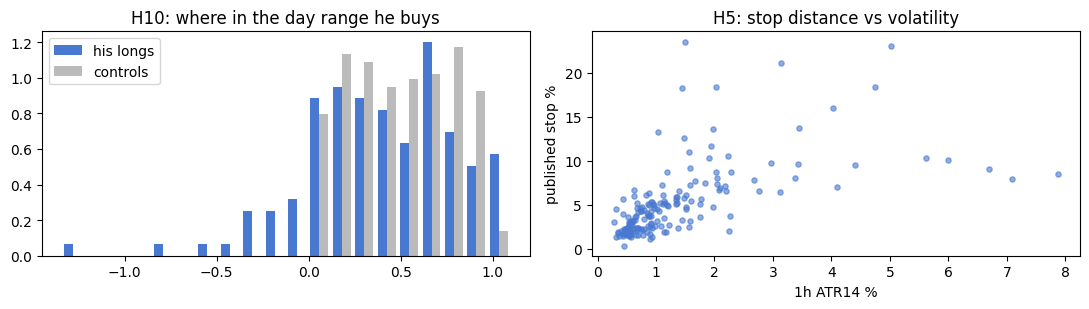

In [4]:
h = pd.read_csv('results/entry_features.csv'); c = pd.read_csv('results/control_features.csv')
hl, cl = h[h.side_sign>0], c[c.side_sign>0]
hs, cs = h[h.side_sign<0], c[c.side_sign<0]
rows = []
for n in (1,3,7):
    rows.append([f'long after new {n}d low (H2)', hl[f'new_low_{n}d'].mean(), cl[f'new_low_{n}d'].mean()])
    rows.append([f'short after new {n}d high (H2)', hs[f'new_high_{n}d'].mean(), cs[f'new_high_{n}d'].mean()])
rows.append(['range position, longs (H10, median)', hl.range_position.median(), cl.range_position.median()])
rows.append(['entry vs 4h EMA200 in ATRs, longs (H4, median)',
             hl.entry_vs_ema200_atr.median(), cl.entry_vs_ema200_atr.median()])
rows.append(['signal in first 30min of 4h candle (H3)',
             (h.min_since_4h_close<=30).mean(), (c.min_since_4h_close<=30).mean()])
t = pd.DataFrame(rows, columns=['feature','his trades','matched controls']).round(3)
display(t)
m = h.dropna(subset=['risk_dist_pct','atr14_1h_pct'])
print(f"H5 stop%% vs ATR%%: pearson {m.risk_dist_pct.corr(m.atr14_1h_pct):.2f}, "
      f"spearman {m.risk_dist_pct.corr(m.atr14_1h_pct, method='spearman'):.2f} (n={len(m)})")
fig, axes = plt.subplots(1, 2, figsize=(11,3.2))
axes[0].hist([hl.range_position.dropna(), cl.range_position.dropna()], bins=20, density=True,
             label=['his longs','controls'], color=['#4878cf','#bbb'])
axes[0].legend(); axes[0].set_title('H10: where in the day range he buys')
axes[1].scatter(m.atr14_1h_pct, m.risk_dist_pct, s=14, alpha=.6, color='#4878cf')
axes[1].set_xlabel('1h ATR14 %'); axes[1].set_ylabel('published stop %')
axes[1].set_title('H5: stop distance vs volatility'); plt.tight_layout()


## 4. Exits, vanished trades, and the real stop
- **H12**: scan the 35 trades that vanish from the channel forward to stop/TP.
- **H11**: after each manual close, how much was still on the table?
- **H3b**: did losing stops see a 4h close beyond them, or only a wick?

In [5]:
un = pd.read_csv('results/unresolved_resolved.csv')
res = un[un.resolution.isin(['stop','target','timeout'])]
print('H12 - the 35 vanished positions:')
print(un.resolution.value_counts().to_string())
if len(res):
    print(f"  vanished trades that hit stop first: {(res.resolution=='stop').sum()}, "
          f"target first: {(res.resolution=='target').sum()}, mean R {res.r.mean():+.2f}")

mfe = pd.read_csv('results/manual_exit_mfe.csv')
print(f"\nH11 - {len(mfe)} manual closes:")
print(f"  median extra favourable move within 72h after his exit: "
      f"{mfe.mfe_after_exit_r_72h.median():+.2f}R")
print(f"  median extra move before his published stop would have hit: "
      f"{mfe.mfe_after_exit_r_before_stop.median():+.2f}R")
print(f"  share leaving >0.5R pre-stop: {(mfe.mfe_after_exit_r_before_stop>0.5).mean():.0%}")

wick = pd.read_csv('results/loss_wick_analysis.csv')
t = wick[wick.wicked_through_stop]
print(f"\nH3b - of {len(t)} losses that touched the stop: "
      f"{t.closed_4h_beyond_stop.sum()} also closed a 4h beyond it, "
      f"{(~t.closed_4h_beyond_stop).sum()} were wick-only")


H12 - the 35 vanished positions:
resolution
stop                           18
unresolvable_missing_fields    12
stop_implausible                2
no_bars                         2
timeout                         1
  vanished trades that hit stop first: 18, target first: 0, mean R -0.56

H11 - 53 manual closes:
  median extra favourable move within 72h after his exit: +0.69R
  median extra move before his published stop would have hit: +0.69R
  share leaving >0.5R pre-stop: 58%

H3b - of 31 losses that touched the stop: 22 also closed a 4h beyond it, 9 were wick-only


## 5. The corrected scoreboard

In [6]:
# corrected scoreboard: reconstructed outcomes + the resolved vanished trades
res = pd.read_csv('results/unresolved_resolved.csv')
res = res[res.resolution.isin(['stop','target','timeout'])]
w0 = (pos.outcome=='win').sum(); l0 = (pos.outcome=='loss').sum(); b0 = (pos.outcome=='breakeven').sum()
wv = ((res.resolution=='target') | ((res.resolution=='timeout') & (res.r>0))).sum()
lv = ((res.resolution=='stop') | ((res.resolution=='timeout') & (res.r<=0))).sum()
print(f"reconstructed: {w0}W/{l0}L/{b0}BE = {w0/(w0+l0)*100:.0f}% ex-BE")
print(f"vanished resolved: +{wv}W/+{lv}L")
print(f"measured:      {w0+wv}W/{l0+lv}L/{b0}BE = {(w0+wv)/(w0+wv+l0+lv)*100:.0f}% ex-BE   "
      f"(his claims: 85% May, 89% July)")


reconstructed: 120W/35L/10BE = 77% ex-BE
vanished resolved: +1W/+18L
measured:      121W/53L/10BE = 70% ex-BE   (his claims: 85% May, 89% July)
